# HQNN EstimatorQNN

### 1. **IMPORTS**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import cat
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
    Identity
)
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix

from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.circuit.library import (
    zz_feature_map,
    pauli_feature_map,
    real_amplitudes,
    efficient_su2,
)
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit import QuantumCircuit
from qiskit_machine_learning.connectors import TorchConnector

### 2. **REPRODUCIBILIDAD (SEED)**

In [2]:
import random
import os
import numpy as np
import torch

SEED = 45

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibilidad CUDA/cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Opcional: operaciones deterministas estrictas
# torch.use_deterministic_algorithms(True)

print(f"Seed fijada: {SEED}")

Seed fijada: 45


In [3]:
transform = transforms.Compose([transforms.ToTensor()])
# transform = transforms.Compose([
#     transforms.Resize((32, 32)),
#     transforms.ToTensor()
# ])

X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [4]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [5]:
train_size = 300
val_size = 100

split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_subset, val_subset = random_split(
    X_train,
    [train_size, val_size],
    generator=split_generator
)

In [6]:
def gaussian_noise(img, sigma=0.25, generator=None):
    noise = torch.randn(
        img.shape,
        generator=generator,
        dtype=img.dtype
    ) * sigma

    return torch.clamp(img + noise, 0, 1)


def salt_pepper(img, prob=0.15, generator=None):
    noisy = img.clone()

    mask = torch.rand(
        img.shape,
        generator=generator,
        dtype=img.dtype
    )

    noisy[mask < prob / 2] = 0
    noisy[mask > 1 - prob / 2] = 1

    return noisy


def speckle(img, sigma=0.35, generator=None):
    noise = torch.randn(
        img.shape,
        generator=generator,
        dtype=img.dtype
    ) * sigma

    return torch.clamp(img + img * noise, 0, 1)


def apply_mixed_noise(img, generator):

    r = torch.randint(
        low=0,
        high=3,
        size=(1,),
        generator=generator
    ).item()

    if r == 0:
        img = gaussian_noise(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 0

    elif r == 1:
        img = gaussian_noise(img, generator=generator)
        img = salt_pepper(img, generator=generator)
        label = 1

    else:
        img = salt_pepper(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 2

    return img, label

In [7]:
class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, seed):
        self.mnist = mnist_dataset

        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.labels = []

        for img, _ in self.mnist:
            noisy_img, label = apply_mixed_noise(
                img,
                generator=self.generator
            )

            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]


train_dataset = NoisyMNISTDataset(train_subset, seed=SEED)
val_dataset   = NoisyMNISTDataset(val_subset, seed=SEED + 1)
test_dataset  = NoisyMNISTDataset(X_test, seed=SEED + 2)

In [8]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=train_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

images, labels = next(iter(train_loader))

print(images.shape)  # [32, 1, 28, 28]
print(labels.shape)


torch.Size([32, 1, 28, 28])
torch.Size([32])


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


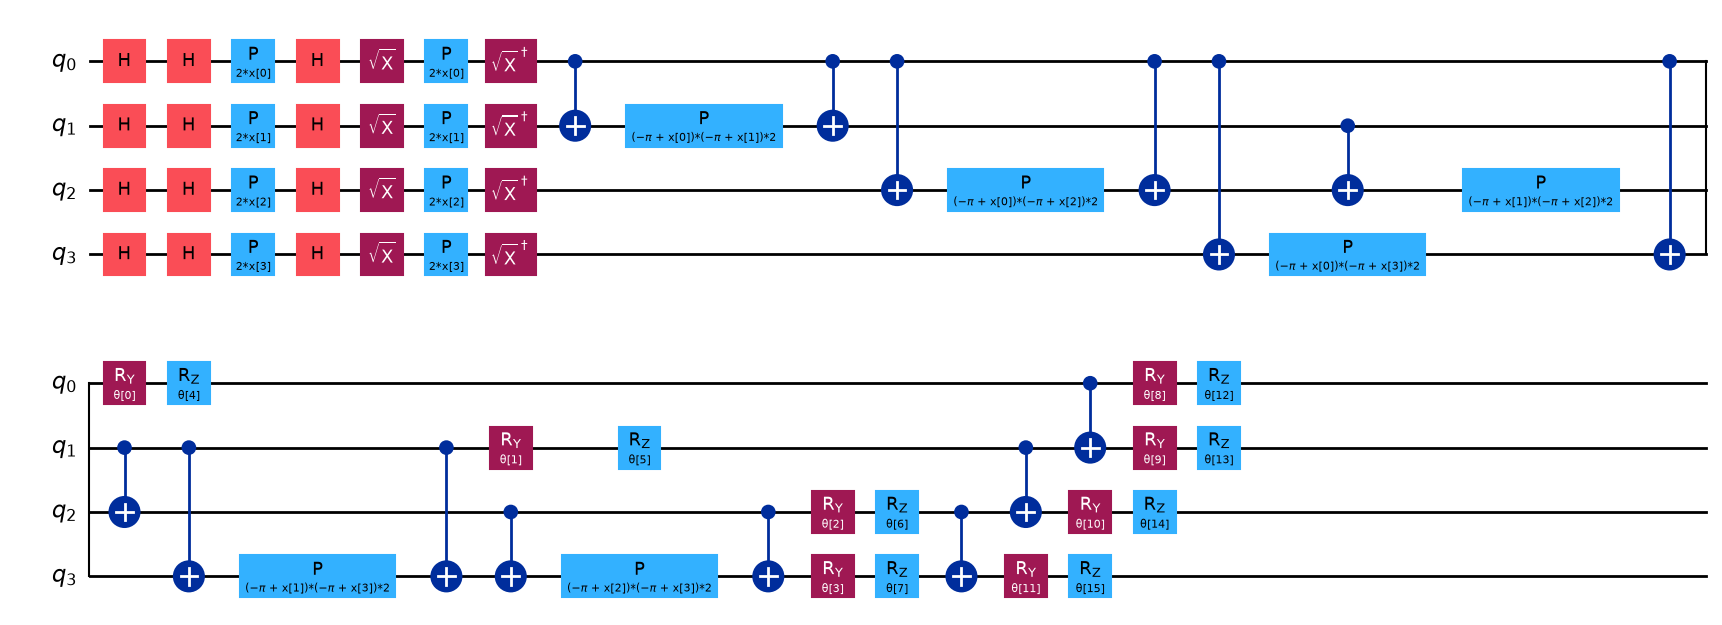

In [9]:
from qiskit.quantum_info import Pauli, SparsePauliOp
# from qiskit.circuit.library import ZZFeatureMap


observables = [
    SparsePauliOp.from_list([("ZIII", 1.0), ("IZII", 1.0)]),
    SparsePauliOp.from_list([("ZZII", 1.0)]),
    SparsePauliOp.from_list([("IIZZ", 1.0)])
] # mejor resultado

estimator = Estimator()
def create_qnn():
    feature_map = pauli_feature_map(4, paulis=["X", "Y", "ZZ"], reps=1, entanglement="full")
    # feature_map = zz_feature_map(4, entanglement="full", reps=1)
    ansatz = efficient_su2(4, entanglement="reverse_linear", reps=1)
    #ansatz = real_amplitudes(4, entanglement="reverse_linear", reps=1)
    qc = QuantumCircuit(4)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)


    # REMEMBER TO SET input_gradients=True FOR ENABLING HYBRID GRADIENT BACKPROP
    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
        observables=observables
    )
    return qnn


qnn = create_qnn()

qnn.circuit.draw("mpl")

In [10]:
class Net(nn.Module):
    def __init__(self, qnn):
        super().__init__()
        # 2 capas convolucionales
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)  # reduce dimensiones a la mitad

        # fully connected
        self.fc1 = nn.Linear(32*7*7, 128)  # flatten 32×7×7=1568
        self.fc2 = nn.Linear(128, 4)      # vector final 4D para QNN

        # QNN
        self.qnn = TorchConnector(qnn)
        # 3Capa lineal final (mapear expectation values → logits 3 clases)
        self.fc_final = nn.Identity()
        # self.fc_final = nn.Linear(len(qnn.observables), 3)
    def forward(self, x):
        # Extracción de features clásicas
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten y proyección fully connected
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x)) * np.pi

        # Forward QNN
        x = self.qnn(x)
        # Capa lineal final → logits:
        x = self.fc_final(x)
        return x

hqnn = Net(qnn)

In [11]:
import torch
print(torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hqnn.to(device)

True


Net(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (qnn): TorchConnector()
  (fc_final): Identity()
)

In [12]:
device

device(type='cuda')

In [13]:
# Separar parámetros correctamente
# optimizer = optim.Adam(hqnn.parameters(), lr=0.001)
optimizer = optim.AdamW(hqnn.parameters(), lr=1e-3)
#optimizer = optim.RMSprop(hqnn.parameters(), lr=1e-3, alpha=0.99, eps=1e-8)

criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss: combina LogSoftmax + NLLLoss, por lo que espera logits sin softmax
# logits = raw outputs del modelo, sin softmax
# LogSoftmax: convierte logits en probabilidades logarítmicas
# NLLLoss: calcula la pérdida negativa logarítmica entre las probabilidades logarítmicas y las etiquetas verdaderas

epochs = 10
# Lista para guardar pérdidas de entrenamiento y validación
train_loss_list = []
val_loss_list = []

# Lista para guardar accuracies
train_acc_list = []
val_acc_list = []
# Calcular tiempo de entrenamiento
import time
start_time = time.time()
patience = 3
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):

    # ==============================
    # Entrenamiento
    # ==============================
    hqnn.train()

    total_loss = 0
    correct = 0
    total = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = hqnn(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)

        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    avg_train_loss = total_loss / total
    train_acc = correct / total

    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)

    # ==============================
    # Validación
    # ==============================
    hqnn.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)

            output = hqnn(data)
            loss = criterion(output, target)

            val_loss += loss.item() * data.size(0)

            _, predicted = torch.max(output, 1)
            correct += (predicted == target).sum().item()
            total += target.size(0)

    avg_val_loss = val_loss / total
    val_acc = correct / total

    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # ==============================
    # Early stopping
    # ==============================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        # Guardar el mejor modelo
        best_model_state = hqnn.state_dict()

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping.")
            break


# tiempo de entrenamiento
end_time = time.time()
training_time = end_time - start_time


# Restaurar el mejor modelo
hqnn.load_state_dict(best_model_state)


print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")


Epoch 1/10 | Train Loss: 1.1279 | Train Acc: 0.3467 | Val Loss: 1.1043 | Val Acc: 0.3200
Epoch 2/10 | Train Loss: 1.0570 | Train Acc: 0.4767 | Val Loss: 0.9865 | Val Acc: 0.5500
Epoch 3/10 | Train Loss: 0.9427 | Train Acc: 0.7400 | Val Loss: 0.8663 | Val Acc: 0.9300
Epoch 4/10 | Train Loss: 0.8108 | Train Acc: 0.9600 | Val Loss: 0.7597 | Val Acc: 0.9200
Epoch 5/10 | Train Loss: 0.7336 | Train Acc: 0.9467 | Val Loss: 0.7034 | Val Acc: 0.9400
Epoch 6/10 | Train Loss: 0.6535 | Train Acc: 0.9833 | Val Loss: 0.5991 | Val Acc: 0.9400
Epoch 7/10 | Train Loss: 0.5714 | Train Acc: 0.9633 | Val Loss: 0.5248 | Val Acc: 0.9800
Epoch 8/10 | Train Loss: 0.4872 | Train Acc: 0.9833 | Val Loss: 0.4860 | Val Acc: 1.0000
Epoch 9/10 | Train Loss: 0.4713 | Train Acc: 0.9867 | Val Loss: 0.4577 | Val Acc: 1.0000
Epoch 10/10 | Train Loss: 0.4494 | Train Acc: 0.9900 | Val Loss: 0.4595 | Val Acc: 0.9900
Tiempo de entrenamiento: 1293.84 segundos
Tiempo en minutos y segundos: 21 minutos y 33 segundos


In [14]:
# ----------------------------
# Evaluación en test
# ----------------------------
hqnn.eval()  # modo evaluación
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = hqnn(data)
        _, preds = torch.max(output, 1)
        all_preds.append(preds.cpu())
        all_targets.append(target.cpu())

# Concatenamos todos los batches
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:")
print(cm)

# Classification report
report = classification_report(all_targets, all_preds, target_names=["gaussian+speckle", "gaussian+saltpepper", "saltpepper+speckle"])
print("\nClassification Report:")
print(report)

# Accuracy total
accuracy = (all_preds == all_targets).float().mean().item()
print(f"\nTest Accuracy: {accuracy:.4f}")

Confusion Matrix:
[[29  0  0]
 [ 0 34  0]
 [ 0  0 37]]

Classification Report:
                     precision    recall  f1-score   support

   gaussian+speckle       1.00      1.00      1.00        29
gaussian+saltpepper       1.00      1.00      1.00        34
 saltpepper+speckle       1.00      1.00      1.00        37

           accuracy                           1.00       100
          macro avg       1.00      1.00      1.00       100
       weighted avg       1.00      1.00      1.00       100


Test Accuracy: 1.0000


---

## 3. Diagnóstico: rango y sesgo de las salidas crudas de la QNN

Antes de modificar nada, conviene comprobar empíricamente una hipótesis: puesto que
`fc_final = nn.Identity()`, los **valores esperados de los observables Pauli se están
usando directamente como logits** de `CrossEntropyLoss`. El primer observable
(`ZIII + IZII`) tiene rango teórico `[-2, 2]`, mientras que los otros dos
(`ZZII`, `IIZZ`) están acotados a `[-1, 1]`. Esa asimetría puede introducir un sesgo
estructural hacia la clase 0 independientemente de la entrada. La siguiente celda
inicializa una QNN con pesos aleatorios (sin entrenar) y observa la salida cruda
sobre un batch real, para contrastar esta hipótesis antes de sacar conclusiones.

In [15]:
# Diagnóstico: distribución de las salidas crudas de la QNN (pesos sin entrenar)
qnn_diag = create_qnn()
net_diag = Net(qnn_diag).to(device)
net_diag.eval()

with torch.no_grad():
    data_diag, target_diag = next(iter(train_loader))
    data_diag = data_diag.to(device)
    raw_out = net_diag(data_diag)

print("Salida cruda de la QNN (antes de entrenar), por observable:")
print("  Mínimo :", raw_out.min(dim=0).values.cpu().numpy())
print("  Máximo :", raw_out.max(dim=0).values.cpu().numpy())
print("  Media  :", raw_out.mean(dim=0).cpu().numpy())
print("  Desv.  :", raw_out.std(dim=0).cpu().numpy())
print()
print("Predicción mayoritaria si no se entrenara nada más:",
      torch.bincount(raw_out.argmax(dim=1)).cpu().numpy())

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Salida cruda de la QNN (antes de entrenar), por observable:
  Mínimo : [-0.14652672 -0.02853249 -0.03905944]
  Máximo : [-0.00695524  0.15402052  0.15246741]
  Media  : [-0.078998    0.0808672   0.06640436]
  Desv.  : [0.03294315 0.04827459 0.04843285]

Predicción mayoritaria si no se entrenara nada más: [ 0 19 13]


---

## 4. HQNN corregida: capa de lectura clásica entrenable tras la QNN

La solución propuesta no modifica el circuito cuántico, sino la interfaz
clásico-cuántica de salida. Se sustituye `fc_final = nn.Identity()` por una capa
`nn.Linear(len(qnn.observables), 3)` — la misma que ya aparecía comentada en el
código original —, de forma que el modelo aprenda una transformación afín (escala
y sesgo por clase) que recalibre los valores esperados antes de la softmax
implícita en `CrossEntropyLoss`. El resto de la arquitectura, el pipeline de datos,
la semilla y el protocolo de entrenamiento se mantienen idénticos a los usados con
la HQNN original, para que la comparación aísle exclusivamente el efecto de este
cambio.

---

## 5. Red clásica equivalente (baseline para la comparativa del TFM)

Para que la comparación clásico-cuántica sea metodológicamente correcta, la red
clásica debe compartir el mismo extractor convolucional de rasgos (`conv1`,
`conv2`, `pool`, `fc1`) y el mismo cuello de botella de dimensión 4 que la HQNN,
sustituyendo únicamente el circuito variacional por una capa densa clásica
`nn.Linear(4, 3)`. Este diseño aísla el efecto específico de la capa cuántica
frente a un bloque clásico de capacidad comparable, en lugar de comparar contra
una arquitectura clásica de profundidad o número de parámetros distintos. La capa
`tanh(·)·π`, que en la HQNN sirve para acotar los ángulos de entrada al feature
map, se elimina aquí por no tener ninguna función en una capa clásica y limitar
innecesariamente su rango dinámico.

In [16]:
class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 4)
        # Sustituye al bloque (TorchConnector + fc_final) de la HQNN
        self.fc_final = nn.Linear(4, 3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc_final(x)
        return x


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

classical_cnn = ClassicalCNN().to(device)

In [17]:
optimizer_classical = optim.AdamW(classical_cnn.parameters(), lr=1e-3)
#optimizer_classical = optim.Adam(classical_cnn.parameters(), lr=0.001)
# mizer_classical = optim.RMSprop(classical_cnn.parameters(), lr=1e-3, alpha=0.99, eps=1e-8)

criterion_classical = nn.CrossEntropyLoss()
epochs = 10
train_loss_list_classical, val_loss_list_classical = [], []
train_acc_list_classical, val_acc_list_classical = [], []
import time
start_time = time.time()
patience = 3
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):

    classical_cnn.train()
    total_loss, correct, total = 0, 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer_classical.zero_grad()
        output = classical_cnn(data)
        loss = criterion_classical(output, target)
        loss.backward()
        optimizer_classical.step()

        total_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    avg_train_loss = total_loss / total
    train_acc = correct / total
    train_loss_list_classical.append(avg_train_loss)
    train_acc_list_classical.append(train_acc)

    classical_cnn.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = classical_cnn(data)
            loss = criterion_classical(output, target)

            val_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output, 1)
            correct += (predicted == target).sum().item()
            total += target.size(0)

    avg_val_loss = val_loss / total
    val_acc = correct / total
    val_loss_list_classical.append(avg_val_loss)
    val_acc_list_classical.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state_classical = classical_cnn.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

end_time = time.time()
training_time_classical = end_time - start_time

classical_cnn.load_state_dict(best_model_state_classical)

print(f"Tiempo de entrenamiento: {training_time_classical:.2f} segundos")

Epoch 1/10 | Train Loss: 1.1033 | Train Acc: 0.4000 | Val Loss: 1.0406 | Val Acc: 0.6100
Epoch 2/10 | Train Loss: 1.0072 | Train Acc: 0.4400 | Val Loss: 0.9691 | Val Acc: 0.4500
Epoch 3/10 | Train Loss: 0.8883 | Train Acc: 0.6567 | Val Loss: 0.8658 | Val Acc: 0.6000
Epoch 4/10 | Train Loss: 0.7804 | Train Acc: 0.6367 | Val Loss: 0.7560 | Val Acc: 0.6700
Epoch 5/10 | Train Loss: 0.7155 | Train Acc: 0.6600 | Val Loss: 0.6644 | Val Acc: 0.6600
Epoch 6/10 | Train Loss: 0.6073 | Train Acc: 0.6633 | Val Loss: 0.5931 | Val Acc: 0.7600
Epoch 7/10 | Train Loss: 0.5235 | Train Acc: 0.7333 | Val Loss: 0.5335 | Val Acc: 0.8100
Epoch 8/10 | Train Loss: 0.4311 | Train Acc: 0.7933 | Val Loss: 0.4247 | Val Acc: 0.9000
Epoch 9/10 | Train Loss: 0.3529 | Train Acc: 0.9267 | Val Loss: 0.3096 | Val Acc: 0.9500
Epoch 10/10 | Train Loss: 0.2719 | Train Acc: 0.9500 | Val Loss: 0.2341 | Val Acc: 0.9500
Tiempo de entrenamiento: 0.58 segundos


In [18]:
classical_cnn.eval()
all_preds_classical, all_targets_classical = [], []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = classical_cnn(data)
        _, preds = torch.max(output, 1)
        all_preds_classical.append(preds.cpu())
        all_targets_classical.append(target.cpu())

all_preds_classical = torch.cat(all_preds_classical)
all_targets_classical = torch.cat(all_targets_classical)

cm_classical = confusion_matrix(all_targets_classical, all_preds_classical)
print("Confusion Matrix (CNN clásica):")
print(cm_classical)

report_classical = classification_report(
    all_targets_classical, all_preds_classical,
    target_names=["gaussian+speckle", "gaussian+saltpepper", "saltpepper+speckle"]
)
print("\nClassification Report (CNN clásica):")
print(report_classical)

accuracy_classical = (all_preds_classical == all_targets_classical).float().mean().item()
print(f"\nTest Accuracy (CNN clásica): {accuracy_classical:.4f}")

Confusion Matrix (CNN clásica):
[[28  0  1]
 [ 0 34  0]
 [ 0  0 37]]

Classification Report (CNN clásica):
                     precision    recall  f1-score   support

   gaussian+speckle       1.00      0.97      0.98        29
gaussian+saltpepper       1.00      1.00      1.00        34
 saltpepper+speckle       0.97      1.00      0.99        37

           accuracy                           0.99       100
          macro avg       0.99      0.99      0.99       100
       weighted avg       0.99      0.99      0.99       100


Test Accuracy (CNN clásica): 0.9900


---

## 6. Comparativa final

La siguiente celda reúne, sin recalcular nada, las métricas ya obtenidas por los
tres modelos entrenados en este notebook bajo idéntico protocolo (misma semilla,
mismo optimizador, mismo *dataset* de ruido mixto y mismo criterio de *early
stopping*), para facilitar su traslado directo a la tabla comparativa del TFM.

In [19]:
print(f"{'Modelo':<22}{'Test Accuracy':>15}{'Tiempo (s)':>14}")
print("-" * 51)
print(f"{'HQNN (original)':<22}{accuracy:>15.4f}{training_time:>14.2f}")
print(f"{'CNN clásica':<22}{accuracy_classical:>15.4f}{training_time_classical:>14.2f}")

Modelo                  Test Accuracy    Tiempo (s)
---------------------------------------------------
HQNN (original)                1.0000       1293.84
CNN clásica                    0.9900          0.58


---

### **GUARDAR EN HTML**

In [20]:
import sys
import subprocess
from pathlib import Path

notebook = Path("Hybrid CNN-QNN.ipynb").resolve()
output_dir = notebook.parent

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "nbconvert",
        "--to", "html",
        str(notebook),
        "--output-dir", str(output_dir),
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("\n--- STDOUT ---")
print(result.stdout)
print("\n--- STDERR ---")
print(result.stderr)

if result.returncode == 0:
    html_file = output_dir / "Hybrid CNN-QNN.html"
    print(f"\n HTML generado correctamente:")
    print(html_file)

RETURN CODE: 0

--- STDOUT ---


--- STDERR ---
[NbConvertApp] Converting notebook C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hcqnn\Hybrid CNN-QNN.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 503474 bytes to C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hcqnn\Hybrid CNN-QNN.html


 HTML generado correctamente:
C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hcqnn\Hybrid CNN-QNN.html
